# Configuration

In [29]:
# * IMPORTS
from pathlib import Path
from typing import Dict, Final
from box import Box
import pandas as pd
import os
from IPython.display import display
from pprint import pprint
import plotly.express as px
from contextlib import redirect_stdout
import mne
import sys

WD = Path.cwd()
sys.path.append(WD)
os.chdir(WD)
assert WD == Path.cwd()

# * RELATIVE IMPORTS
# from analysis_conf import Config as c
# from data_loader.human_data import HumanSessData, HumanSubjData, HumanGroupData
# from utils.analysis_utils import read_file, list_contents
# from analysis_compare_clean import CombinedData
from ar_analysis.data_loader.human_data import (
    HumanSessData,
    HumanSubjData,
    HumanGroupData,
)
from ar_analysis.data_loader.ann_data import (
    ANNSubjData,
    ANNGroupData,
)

from ar_analysis.utils.custom_type_hints import DATA_FMTS
from ar_analysis.utils.analysis_utils import (
    read_file,
    reorder_item_ids,
    list_contents,
)
from ar_analysis.analysis_rsa import get_ds_and_rdm
from ar_analysis.analysis_config import Config as c

# from ar_analysis.utils.analysis_utils import xdir

# ! TEMP: to locate and use ffmpeg
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ["PATH"]

In [30]:
# * GLOBAL VARIABLES
PATTERNS = c.PATTERNS
ANN_ID_MAPPING = c.ANN_ID_MAPPING
ANN_ID_ORDER = c.ANN_ID_ORDER

DATASET = c.DATASET
SEQ_FILE = c.SEQ_FILE
# DIRECTORIES = c.DIRECTORIES

SAVE_DISK: Final = Path("/Volumes/Realtek 1Tb")
# SAVE_DISK: Final = Path("/Volumes/SSD-512Go")
assert SAVE_DISK.exists(), "WARNING: SSD not connected"
MAIN_DATA_DIR = SAVE_DISK / "PhD Data/experiment1/data/"
DIRECTORIES: Final = Box(
    {
        "ann": {
            "data": MAIN_DATA_DIR
            / "ANNs/local_run/sessions-1_to_5-masked_idx(7)-sequence_tokens_acts",
            "prepro": None,
            "analyzed": MAIN_DATA_DIR / "ANNs/analyzed",
            "export": MAIN_DATA_DIR / "ANNs/analyzed",
        },
        "human": {
            "data": MAIN_DATA_DIR / "Lab/raw-BIDS3",
            "prepro": MAIN_DATA_DIR / "Lab/preprocessed",
            "analyzed": MAIN_DATA_DIR / "Lab/analyzed",
            "export": MAIN_DATA_DIR / "Lab/analyzed",
        },
    }
)


# Human Data

### Load Data

In [31]:
this_sess = HumanSessData(
    DIRECTORIES.human.data,
    DIRECTORIES.human.prepro,
    DIRECTORIES.human.export,
    subj_N=1,
    sess_N = 1
)

this_subj = HumanSubjData(
    DIRECTORIES.human.data,
    DIRECTORIES.human.prepro,
    DIRECTORIES.human.export,
    subj_N=1,
)

# this_sess = this_subj.sessions[1]

human_group = HumanGroupData(
    DIRECTORIES.human.data,
    DIRECTORIES.human.prepro,
    DIRECTORIES.human.export,
)


In [32]:
human_group.show_dir_struct()

Human Data Root Directory Structure:
raw-BIDS3/
├── dataset_description.json
├── participants.json
├── participants.tsv
├── README
├── sub-01/
│   ├── ses-01/
│   │   ├── beh/
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_beh.json
│   │   │   └── sub-01_ses-01_task-AbsPattComp_beh.tsv
│   │   ├── eeg/
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_channels.tsv
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_eeg.bdf
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_eeg.json
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_events.json
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_events.tsv
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physio.json
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physio.tsv.gz
│   │   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physioevents.json
│   │   │   └── sub-01_ses-01_task-AbsPattComp_recording-eye1_physioevents.tsv.gz
│   │   └── sub-01_ses-01_scans.tsv
│   ├── ses-02/
│   │   ├── beh/
│   │   │   ├── sub-01_ses-

In [7]:
list(this_sess.get_raw_behav_data().columns)

['subj_id',
 'trial_type',
 'item_id',
 'trial_onset_time',
 'series_end_time',
 'choice_onset_time',
 'rt',
 'rt_global',
 'choice_key',
 'solution_key',
 'choice',
 'solution',
 'correct',
 'pattern',
 'blockN',
 'iti']

In [18]:
sess_info = human_group.get_sess_info()

In [9]:
_df_sess_info = []
for subj_N, subj_info in sess_info.items():
    for sess_N, sessions_info in subj_info.items():
        _df = pd.DataFrame.from_dict(sessions_info, orient='index').T
        _df['subj_N'] = subj_N
        _df["sess_N"] = sess_N
        _df_sess_info.append(_df)
        
df_sess_info = pd.concat(_df_sess_info).reset_index(drop=True)

print(f"{df_sess_info['img_size'].unique() = }")
print(f"{df_sess_info['window_size'].unique() = }")
print(f"{df_sess_info['eye'].unique() = }")
print(f"{df_sess_info['vision_correction'].unique() = }")

df_sess_info

df_sess_info['img_size'].unique() = array(['256, 256'], dtype=object)
df_sess_info['window_size'].unique() = array(['2560, 1440'], dtype=object)
df_sess_info['eye'].unique() = array(['left', 'right'], dtype=object)
df_sess_info['vision_correction'].unique() = array(['glasses', 'none', 'contacts'], dtype=object)


,session_id,vision_correction,eye,eye_screen_dist,window_size,img_size,notes,subj_N,sess_N
0,ses-01,glasses,left,650,"2560, 1440","256, 256",,13,1
1,ses-02,glasses,left,635,"2560, 1440","256, 256",The participant moved a bit during the experim...,13,2
2,ses-01,none,left,650,"2560, 1440","256, 256",,14,1
3,ses-02,none,left,628,"2560, 1440","256, 256",,14,2
4,ses-03,none,left,640,"2560, 1440","256, 256",,14,3
...,...,...,...,...,...,...,...,...,...
103,ses-01,contacts,left,650,"2560, 1440","256, 256",,4,1
104,ses-02,contacts,left,620,"2560, 1440","256, 256",,4,2
105,ses-03,contacts,left,620,"2560, 1440","256, 256","eye to screen distqnce was on cm, so it has no...",4,3
106,ses-04,contacts,left,620,"2560, 1440","256, 256",,4,4


In [10]:
physio_jsons = [read_file(f) for f in list_contents(human_group.data_dir, reg=r".+_physio.json$")]
physio_jsons

[{'Manufacturer': 'SR-Research',
  'PhysioType': 'eyetrack',
  'Columns': ['timestamp', 'x_coordinate', 'y_coordinate', 'pupil_size'],
  'timestamp': {'Description': 'a continuously increasing identifier of the sampling time registered by the device',
   'Units': 'ms',
   'Origin': 'System startup'},
  'x_coordinate': {'LongName': 'Gaze position (x)',
   'Description': 'Gaze position x-coordinate of the recorded eye, in the coordinate units specified in the corresponding metadata sidecar.',
   'Units': 'pixel'},
  'y_coordinate': {'LongName': 'Gaze position (y)',
   'Description': 'Gaze position y-coordinate of the recorded eye, in the coordinate units specified in the corresponding metadata sidecar.',
   'Units': 'pixel'},
  'pupil_size': {'Description': "Pupil area of the recorded eye as calculated by the eye-tracker in arbitrary units (see EyeLink's documentation for conversion).",
   'Units': 'a.u.'},
  'SoftwareVersion': 'EYELINK II CL v5.50 Jun 16 2022 (EyeLink 1000 Plus)',
  'Sa

In [10]:
# ks = ["AverageCalibrationError", "MaximalCalibrationError"]
# res = []
# for pj in physio_jsons:
#     for k in ks:
#         res.extend(pj[k][0])

### Analyze Data

####  Subject Level

In [24]:
this_subj.show_dir_struct()

Subject 01 - Directory Structure:
sub-01/
├── ses-01/
│   ├── beh/
│   │   ├── sub-01_ses-01_task-AbsPattComp_beh.json
│   │   └── sub-01_ses-01_task-AbsPattComp_beh.tsv
│   ├── eeg/
│   │   ├── sub-01_ses-01_task-AbsPattComp_channels.tsv
│   │   ├── sub-01_ses-01_task-AbsPattComp_eeg.bdf
│   │   ├── sub-01_ses-01_task-AbsPattComp_eeg.json
│   │   ├── sub-01_ses-01_task-AbsPattComp_events.json
│   │   ├── sub-01_ses-01_task-AbsPattComp_events.tsv
│   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physio.json
│   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physio.tsv.gz
│   │   ├── sub-01_ses-01_task-AbsPattComp_recording-eye1_physioevents.json
│   │   └── sub-01_ses-01_task-AbsPattComp_recording-eye1_physioevents.tsv.gz
│   └── sub-01_ses-01_scans.tsv
├── ses-02/
│   ├── beh/
│   │   ├── sub-01_ses-02_task-AbsPattComp_beh.json
│   │   └── sub-01_ses-02_task-AbsPattComp_beh.tsv
│   ├── eeg/
│   │   ├── sub-01_ses-02_task-AbsPattComp_channels.tsv
│   │   ├── sub-01_ses-0

Now let's look at this subject's performance

In [25]:
this_subj_behav = this_subj.get_behav_data()
display(this_subj_behav.head())

agg_level = "session"  # "subject" or "session"
this_subj_perf_res = this_subj.analyze_perf(agg="subject")
perf_res_keys = this_subj_perf_res.keys()

print(f"Perfomance results' keys:{''.join([f'\n  - {k}' for k in perf_res_keys])}")

display(this_subj_perf_res["acc_by_patt"].head())


,subj_N,sess_N,trial_N,block_N,item_id,rt,choice_key,solution_key,choice,solution,...,figure7,figure8,choice1,choice2,choice3,choice4,masked_idx,seq_order,choice_order,trial_type
0,1,1,0,0,612709,6.602594,l,l,star,star,...,truck,star,eye,truck,guitar,star,7,14326750,3120,experiment
1,1,1,1,0,323333,4.029402,m,m,sun,sun,...,key,sun,key,heart,sun,star,7,43751260,1320,experiment
2,1,1,2,0,575122,10.049137,x,a,key,eye,...,truck,eye,eye,key,truck,cube,7,14730652,1302,experiment
3,1,1,3,0,539521,NaN,timeout,l,timeout,bulb,...,carrot,bulb,key,hammer,heart,bulb,7,31726540,0213,experiment
4,1,1,4,0,651002,4.509872,l,m,helicopter,eye,...,truck,eye,truck,star,eye,helicopter,7,62531047,1023,experiment


Perfomance results' keys:
  - overall_acc
  - overall_rt
  - acc_by_patt
  - rt_by_patt
  - rt_by_crct
  - rt_by_crct_and_patt


,count,mean,std,min,25%,50%,75%,max
pattern,,,,,,,,
AAABAAAB,50.0,0.98,0.141421,0.0,1.0,1.0,1.0,1.0
ABABCDCD,50.0,0.94,0.239898,0.0,1.0,1.0,1.0,1.0
ABBAABBA,50.0,0.98,0.141421,0.0,1.0,1.0,1.0,1.0
ABBACDDC,50.0,0.92,0.274048,0.0,1.0,1.0,1.0,1.0
ABBCABBC,50.0,0.82,0.388088,0.0,1.0,1.0,1.0,1.0


##### Create trial video

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=3061427
    Range : 0 ... 3061426 =      0.000 ...  1530.713 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 79 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


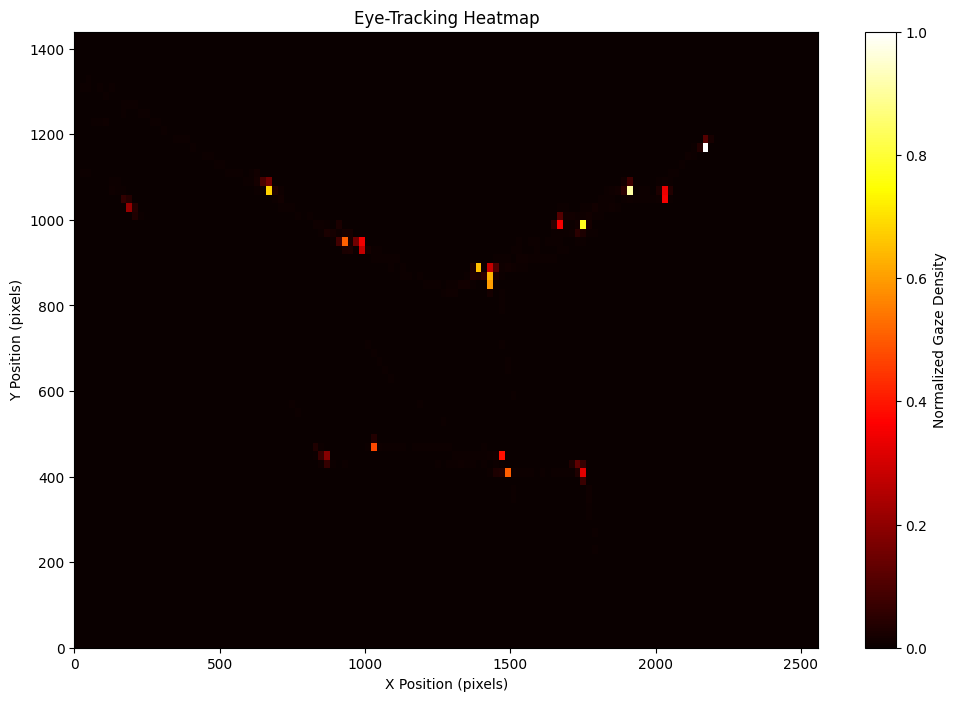

Saving frames in TEST/subj01_ses01/trial30_frames/eeg_frames-1-01-ep30


Generating frames:   0%|          | 0/181 [00:00<?, ?it/s]

Creating video with FFmpeg...


ffmpeg version 8.1.1 Copyright (c) 2000-2026 the FFmpeg developers
  built with Apple clang version 21.0.0 (clang-2100.0.123.102)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/8.1.1 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags= --enable-ffplay --enable-gpl --enable-libsvtav1 --enable-libopus --enable-libx264 --enable-libmp3lame --enable-libdav1d --enable-libvmaf --enable-libvpx --enable-libx265 --enable-openssl --enable-videotoolbox --enable-audiotoolbox --enable-neon
  libavutil      60. 26.101 / 60. 26.101
  libavcodec     62. 28.101 / 62. 28.101
  libavformat    62. 12.101 / 62. 12.101
  libavdevice    62.  3.101 / 62.  3.101
  libavfilter    11. 14.101 / 11. 14.101
  libswscale      9.  5.101 /  9.  5.101
  libswresample   6.  3.101 /  6.  3.101
Input #0, image2, from 'TEST/subj01_ses01/trial30_frames/eeg_frames-1-01-ep30/frame_%03d.png':
  Duration: 00:01:00.67, start: 0.000000, bitrate: N/A
  Stream #0:0: Video: png, rgba(pc

Video created: eeg_video-subj01-sess01-ep30.mp4


[out#0/mp4 @ 0xbd6c28240] video:8700KiB audio:0KiB subtitle:0KiB other streams:0KiB global headers:0KiB muxing overhead: 0.034955%
frame=  182 fps= 26 q=-1.0 Lsize=    8703KiB time=00:01:00.00 bitrate=1188.2kbits/s speed= 8.6x elapsed=0:00:06.97    
[libx264 @ 0xbd7020a80] frame I:1     Avg QP: 5.20  size: 72025
[libx264 @ 0xbd7020a80] frame P:59    Avg QP:21.99  size:119189
[libx264 @ 0xbd7020a80] frame B:122   Avg QP:24.46  size: 14784
[libx264 @ 0xbd7020a80] consecutive B-frames:  6.0%  9.9% 11.5% 72.5%
[libx264 @ 0xbd7020a80] mb I  I16..4: 75.8% 20.8%  3.4%
[libx264 @ 0xbd7020a80] mb P  I16..4:  1.5%  3.8%  2.9%  P16..4:  1.6%  0.9%  0.3%  0.0%  0.0%    skip:88.9%
[libx264 @ 0xbd7020a80] mb B  I16..4:  0.7%  1.3%  0.5%  B16..8:  3.5%  1.2%  0.2%  direct: 0.3%  skip:92.2%  L0:50.8% L1:46.5% BI: 2.7%
[libx264 @ 0xbd7020a80] 8x8 transform intra:45.4% inter:79.2%
[libx264 @ 0xbd7020a80] coded y,uvDC,uvAC intra: 28.1% 52.6% 27.9% inter: 1.2% 1.2% 0.3%
[libx264 @ 0xbd7020a80] i16 v,h,dc,

PosixPath('TEST/subj01_ses01/trial30_frames/eeg_frames-1-01-ep30/eeg_video-subj01-sess01-ep30.mp4')

In [26]:
# # * Load the data & Split it into trials
sess_info, behav, eeg, et = this_sess.get_data()

(
    manual_et_trials,
    *_,
    # et_events_dict,
    # et_events_dict_inv,
    # et_trial_bounds,
    # et_trial_events_df,
) = this_sess.split_et_data_into_trials(et)

(
    manual_eeg_trials,
    *_,
    # eeg_trial_bounds,
    # eeg_events,
    # eeg_events_df,
) = this_sess.split_eeg_data_into_trials(eeg, behav)


manual_et_trials = list(manual_et_trials)
manual_eeg_trials = list(manual_eeg_trials)

# * Generate a video for one trial
trial_N = 30
save_dir = Path(
    f"./TEST/subj{this_sess.subj_N:02}_ses{this_sess.sess_N:02}/trial{trial_N}_frames"
)
save_dir.mkdir(exist_ok=True, parents=True)

this_sess.generate_trial_video(
    manual_et_trials,
    manual_eeg_trials,
    behav,
    trial_N,
    # all_bad_chans: Optional[Dict] = None,
    # eeg_chan_groups: Optional[Dict] = None,
    # non_eeg_chans: Optional[List[str]] = None,
    # et_sfreq: Union[int, float, NoneType] = None,
    # valid_events_inv: Optional[Dict] = None,
    # eeg_sfreq: Union[int, float, NoneType] = None,
    # screen_resolution: Optional[Tuple[int, int]] = None,
    # icon_images: Optional[Dict[str, numpy.ndarray]] = None,
    save_dir=save_dir,
    gaze_pt_size=10,
    # gaze_ln_size = None
)


##### Sesssion Data

Let's get locate in which trials and in which presentation order each stimulus is shown

In [27]:
stim_flash_order = this_subj.get_stim_flash_order()
display(stim_flash_order.dropna())

,subj_N,sess_N,trial_N,all_stim_flash_seq,stim_locs,stim_flash_order,stim
8,1,1,8,"[6, 5, 2, 3, 0, 1, 4, 7, 11, 9, 8, 10]","[0, 4, 9]","[4, 6, 9]",bell
9,1,1,9,"[1, 2, 4, 0, 5, 3, 6, 7, 9, 10, 11, 8]","[0, 7, 10]","[3, 7, 9]",bell
13,1,1,13,"[5, 1, 0, 4, 7, 3, 6, 2, 10, 11, 8, 9]","[4, 5, 11]","[0, 3, 9]",bell
17,1,1,17,"[2, 4, 0, 3, 6, 5, 1, 7, 8, 9, 11, 10]",[11],[10],bell
21,1,1,21,"[7, 1, 3, 0, 4, 6, 2, 5, 11, 10, 8, 9]","[0, 3, 9]","[2, 3, 11]",bell
...,...,...,...,...,...,...,...
6381,1,5,61,"[0, 2, 4, 1, 7, 6, 5, 3, 9, 11, 8, 10]","[2, 7, 11]","[1, 4, 9]",wheat
6389,1,5,69,"[1, 2, 5, 6, 7, 0, 3, 4, 11, 9, 8, 10]","[1, 5, 9]","[0, 2, 9]",wheat
6392,1,5,72,"[2, 4, 3, 5, 1, 0, 6, 7, 10, 11, 9, 8]","[1, 2, 10]","[0, 4, 8]",wheat
6396,1,5,76,"[7, 1, 4, 5, 0, 2, 3, 6, 10, 11, 9, 8]","[1, 6, 8]","[1, 7, 11]",wheat


In [28]:
ind = 0
row = stim_flash_order.dropna().iloc[ind : ind + 1]
display(row)

row = Box(row.iloc[0].to_dict())
# trial_N = row.overall_trial_N
trial_N = row.trial_N
stim = row.stim

print(
    f"""
`{row.stim}` is present in trial {row.trial_N} of session {row.sess_N} for subject
{row.subj_N} and is flashed at time slot(s) {row.stim_flash_order} of the encoding phase
""".replace("\n", " ").strip()
)

seq = ["[]" if i not in row.stim_locs else row.stim for i in range(8)]
options = ["[]" if i not in row.stim_locs else row.stim for i in range(8, 13)]

print(
    f"\nSpatial arrangment of this stimulus in the trial:\n\tSequence: {' '.join(seq)}\n\tOptions: {' '.join(options)}"
)


,subj_N,sess_N,trial_N,all_stim_flash_seq,stim_locs,stim_flash_order,stim
8,1,1,8,"[6, 5, 2, 3, 0, 1, 4, 7, 11, 9, 8, 10]","[0, 4, 9]","[4, 6, 9]",bell


`bell` is present in trial 8 of session 1 for subject 1 and is flashed at time slot(s) [4, 6, 9] of the encoding phase

Spatial arrangment of this stimulus in the trial:
	Sequence: bell [] [] [] bell [] [] []
	Options: [] bell [] [] []


In [29]:
fig_cols = [f"figure{i}" for i in range(1, 9)]
choice_cols = [f"choice{i}" for i in range(1, 5)]

trial_data = sequence = this_subj_behav.query(
    f"sess_N == {row['sess_N']} & trial_N=={row['trial_N']}"
)
trial_sequence = trial_data[fig_cols]
trial_choices = trial_data[choice_cols]

print(f"Sequence: {' '.join(trial_sequence.values[0].tolist())}")
print(f"Options: {' '.join(trial_choices.values[0].tolist())}")

Sequence: bell guitar guitar key bell guitar guitar key
Options: eye bell guitar key


Here's the average EEG activity for that stimulus across all trials of this session

Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 1 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 1 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events and 1230 original time points ...
0 bad epochs dropped
Loading data for 3 events an

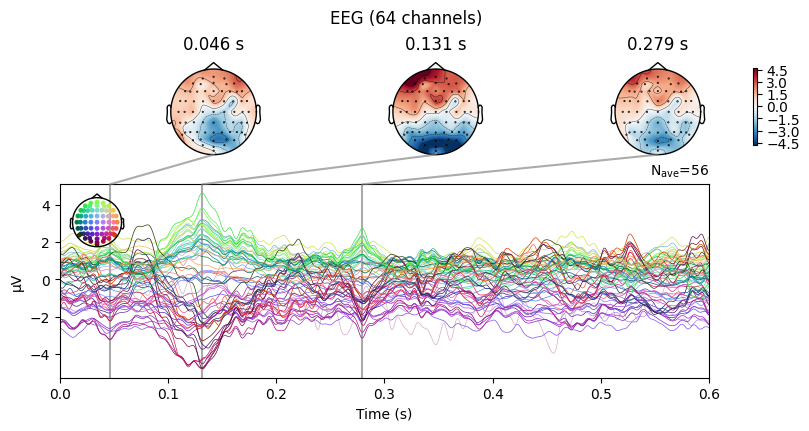

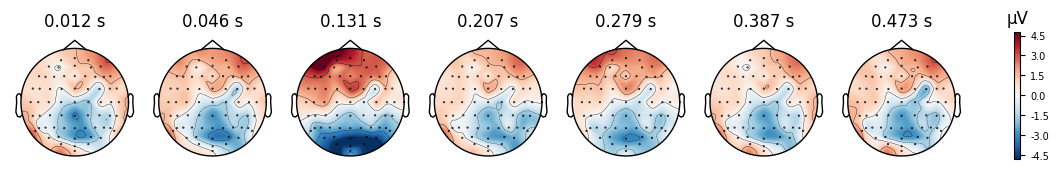

    Using multitaper spectrum estimation with 7 DPSS windows


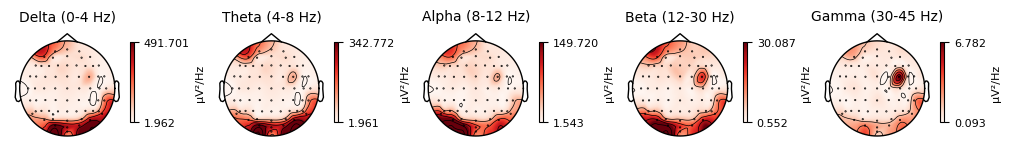

In [30]:
stim_flash_eeg_sess_epochs = this_sess.get_stim_flash_eeg_epochs(stim)
sess_stim_erp = stim_flash_eeg_sess_epochs[stim].average()

sess_stim_erp_plot = sess_stim_erp.plot_joint()
sess_stim_erp_plot_psd = sess_stim_erp.plot_topomap(times="peaks", ch_type="eeg")
all_sess_stim_erp_plot = sess_stim_erp.compute_psd().plot_topomap()

And here's the average EEG activity for that stimulus across all trials and sessions

  0%|          | 0/5 [00:00<?, ?it/s]

/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:282: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_eeg = mne.io.read_raw_bdf(eeg_fpath, preload=preload, verbose=verbose)


No projector specified for this dataset. Please consider the method self.add_proj.


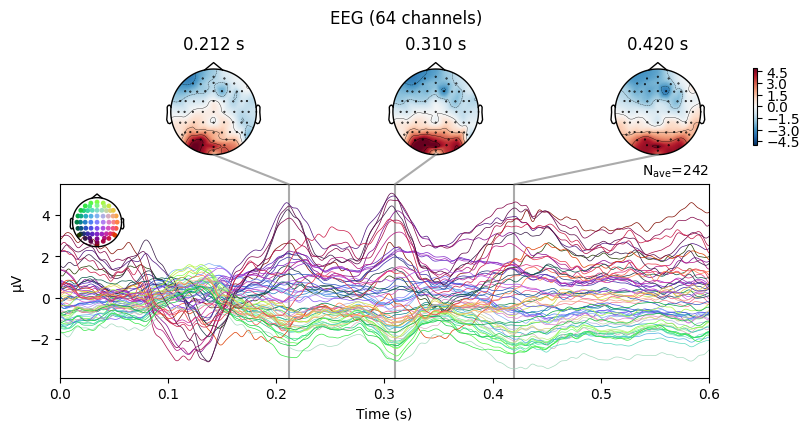

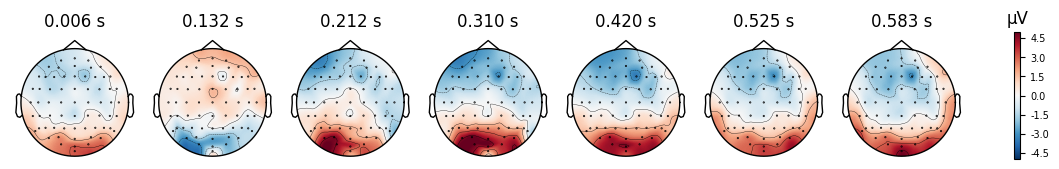

    Using multitaper spectrum estimation with 7 DPSS windows


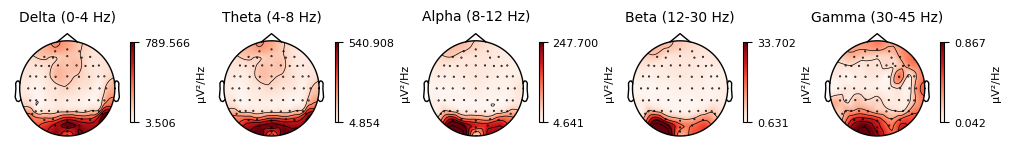

In [31]:
stim_flash_eeg_all_sess_epochs = this_subj.get_stim_flash_eeg_epochs(stim)

all_sess_stim_erp = stim_flash_eeg_all_sess_epochs[stim].average()

all_sess_stim_erp_plot = all_sess_stim_erp.plot_joint()
all_sess_stim_erp_plot_topo = all_sess_stim_erp.plot_topomap(
    times="peaks", ch_type="eeg"
)
all_sess_stim_erp_plot_psd = all_sess_stim_erp.compute_psd().plot_topomap()


We can also get the ERP associated with any recorded EEG events

In [32]:
response_events = this_subj_behav["solution_key"].unique().tolist()
print(f"{response_events = }")

response_events = ['l', 'm', 'a', 'x']


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:282: RuntimeWarning: Number of records from the header does not match the file size (perhaps the recording was not stopped before exiting). Inferring from the file size.
  raw_eeg = mne.io.read_raw_bdf(eeg_fpath, preload=preload, verbose=verbose)


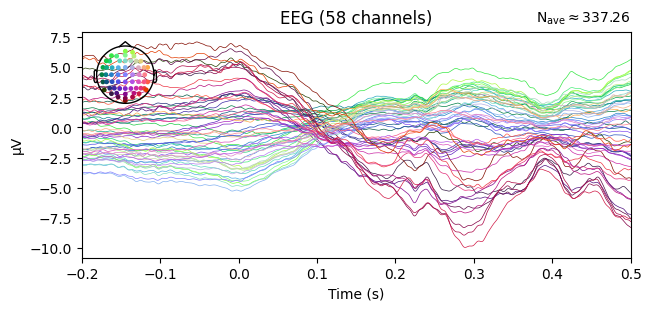

In [33]:
selected_events = response_events  # ['trial_start']

with redirect_stdout(open(os.devnull, "w")):
    this_subj_erps = this_subj.get_erp(
        selected_events, tmin=-0.2, tmax=0.5, erp_by_sess=True
    )
# this_subj.get_erp?

all_sess_erp = mne.combine_evoked(list(this_subj_erps.values()), weights="equal")
erp_plot = all_sess_erp.plot()

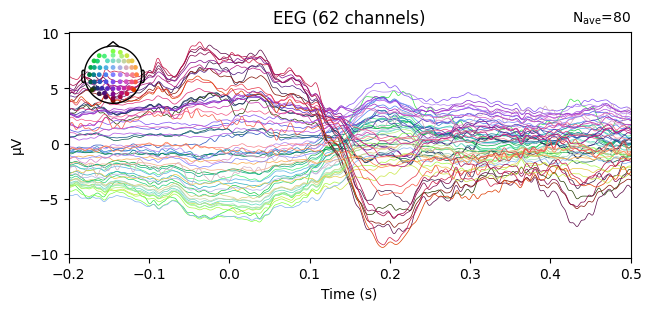

In [34]:
this_sess_erp, this_sess_ch_names = (
    this_subj_erps[1].get_data(),
    this_subj_erps[1].info["ch_names"],
)
this_subj_erps[1].plot()

this_sess_erp = pd.DataFrame(this_sess_erp.T, columns=this_sess_ch_names)

px.line(
    this_sess_erp,
    labels={"value": "Amplitude", "index": "Time (ms)", "variable": "Channel"},
    title="ERP Subj 1 - Sess 1",
    width=650,
    height=500,
)

##### Analyze all sessions

In [35]:
this_sess_res = this_sess.analyze_session(
    save_dir=WD / "analysis/test-export",
    preprocessed_dir=DIRECTORIES.human.prepro,
)

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=3061427
    Range : 0 ... 3061426 =      0.000 ...  1530.713 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 79 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Analyzing every trial:   0%|          | 0/80 [00:00<?, ?it/s]

ValueError: Buffer has wrong number of dimensions (expected 1, got 2)

In [ ]:
(
    sess_frps,
    fixation_data,
    eeg_fixation_data,
    gaze_info,
    gaze_target_fixation_sequence,
) = this_sess_res


In [ ]:
all_sess_res = this_subj.analyze_sessions(
    save_dir=WD / "analysis/test-export",
    preprocessed_dir=DIRECTORIES.human.prepro,
    force_preprocess=False,
    reuse_ica=True,
    raise_error=False,
)

In [ ]:
# (
#     sess_frps,
#     fixation_data,
#     eeg_fixation_data,
#     gaze_info,
#     gaze_target_fixation_sequence,
# ) = all_sess_res[5]

In [ ]:
# pprint(sess_frps)
# sess_frps['sequence'][0].plot()
gaze_info
gaze_target_fixation_sequence.groupby("trial_N")["target_ind"].value_counts()
gaze_target_fixation_sequence.query("trial_N==3")
# _fix = fixation_data[1][0]
# plt.plot(_fix[0], _fix[1])

##### Stimuli ERPs

In [ ]:
stim_flash_eeg_eps = this_subj.get_stim_flash_eeg_epochs()
stim_flash_erps = {stim: eps.average() for stim, eps in stim_flash_eeg_eps.items()}

In [ ]:
print(f"Stimuli: {', '.join(stim_flash_erps.keys())}")

In [ ]:
selected_stims = {
    stim: stim_flash_erps[stim] for stim in ["helicopter", "smile", "eye"]
}

with redirect_stdout(open(os.devnull, "w")):
    for i, (stim, erp) in enumerate(selected_stims.items()):
        erp.plot_joint(title=stim)

#### Group level

In [ ]:
human_group.show_dir_struct()

In [ ]:
eeg_metadata = human_group.extract_eeg_metadata()


In [ ]:
combined_stats, acc_fig, rt_fig, scatter = human_group.summarize_behav()

In [ ]:
human_group_behav = human_group.get_behav_data()
human_group_behav["correct"] = human_group_behav["correct"].astype(int)

human_group_acc_stats = human_group_behav.groupby(["sess_N", "subj_N"], observed=False)[
    "correct"
].describe()

display(human_group_acc_stats)


In [ ]:
sns.lineplot(
    data=human_group_behav, x="subj_N", y="correct", hue="sess_N", errorbar=None
)
plt.show()

plots_kwargs = [
    dict(data=human_group_behav, x="sess_N", y="correct"),
    dict(data=human_group_behav, x="sess_N", y="correct", hue="pattern"),
]
for kwargs in plots_kwargs:
    fig, ax = plt.subplots()
    sns.lineplot(ax=ax, **kwargs)
    ax.set_xticks(range(1, 6))
    plt.show()


In [ ]:
human_group_acc_stats.query("subj_N==1")

# LLM Data

### Load Data

In [3]:
root_data_dir = Path("/Volumes/Realtek 1Tb/PhD Data/experiment1/data")
ann_data_dir = (
    root_data_dir / "ANNs/local_run/sessions-1_to_5-masked_idx(7)-sequence_tokens_acts"
)
ann_export_dir = Path("/Volumes/Realtek 1Tb/PhD Data/experiment1-analysis/ANNs")

qwen2_5_72B = ANNSubjData(
    ann_data_dir, ann_export_dir, ann_id="Qwen--Qwen2.5-72B-Instruct"
)
ann_group = ANNGroupData(ann_data_dir, ann_export_dir)

FileNotFoundError: ANN directory not found: /Volumes/Realtek 1Tb/PhD Data/experiment1/data/ANNs/local_run/sessions-1_to_5-masked_idx(7)-sequence_tokens_acts/Qwen--Qwen2.5-72B-Instruct

### Analyze Data

In [ ]:
print("\n".join([i for i in dir(qwen2_5_72B) if not i.startswith("_")]))

In [ ]:
qwen2_5_72B_behav = qwen2_5_72B.get_behav_data()
qwen2_5_72B_behav.head()
# qwen2_5_72B.get_behav_rdms()
# qwen2_5_72B.get_layer_acts()
# qwen2_5_72B.list_contents()
# qwen2_5_72B.get_run_info()
# qwen2_5_72B.get_rdms_on_all_layers()

In [ ]:
ann_group_behav = ann_group.get_behav_data().merge(
    DATASET, on=["item_id", "masked_idx", "pattern", "solution"]
)

# category_cols = {i:"category" for i in (
#     ["ann_id", "pattern", "item_id", "trial_type"]
#     + [f"figure{i}" for i in range(1, 9)]
#     + [f"choice{i}" for i in range(1, 5)]
# )}
# ann_group_behav = ann_group_behav.astype(category_cols)

ann_group_behav.head(3)

In [ ]:
n_items = len(DATASET)
n_item_per_patt = list(set(DATASET.groupby(["pattern"])["item_id"].nunique()))[0]
ann_ids = ann_group_behav["ann_id"].unique()
pattern_index = pd.MultiIndex.from_product(
    [PATTERNS, ann_ids], names=["pattern", "ann_id"]
)

q = "cleaned_response==figure7 & cleaned_response!=solution"

copying_df = (
    ann_group_behav.query(q).groupby(["ann_id"])["pattern"].value_counts().reset_index()
)

copying_df["count"] /= n_item_per_patt
copying_df = copying_df.rename(columns={"count": "pct_copying"})

copying_df = (
    pattern_index.to_frame(index=False)
    .merge(copying_df, on=["pattern", "ann_id"], how="left")
    .fillna(0)
)

copying_df["ann_id"] = copying_df["ann_id"].str.replace(".+--", "", regex=True)
display(copying_df.head(5))


pivot_df = copying_df.pivot(index="pattern", columns="ann_id", values="pct_copying").T
print("Percent of trials where model repeated last visible element, per pattern type:")
pivot_df.style.background_gradient(axis=1, cmap="YlOrRd").format(precision=2)


# Combined Analysis

In [ ]:
combined_data = CombinedData(DIRECTORIES.ann, DIRECTORIES.human, SEQ_FILE)

In [ ]:
print("combined_data available methods/properties:")
print("\n".join([f"\t- {i}" for i in dir(combined_data) if not i.startswith("_")]))

## Compare Performance

In [ ]:
perf_data_all = combined_data.get_perf_data()
print(f"columns: {perf_data_all.columns.tolist()} ")
display(perf_data_all.head())

In [ ]:
perf_data_all.groupby("type")["correct"].describe()
perf_data_all.groupby(["pattern", "type"])["correct"].mean()
# perf_data_all.groupby("id")['correct'].mean()

## Representational Similarity Analysis

In [ ]:
human_ds, llm_ds = combined_data.get_rsa_datasets(
    human_data_dir=DIRECTORIES.human.analyzed / "RSA-FRP-frontal",
    ann_data_dir=DIRECTORIES.ann.analyzed
    / "RSA-seq_tokens-metric_correlation/best_layer",
    level="pattern",
)

In [ ]:
rsa_repr = combined_data.compare_representations(
    human_ds,
    llm_ds,
    n_perm=0,
    n_boot=0,
    boot_conf_int=(2.5, 97.5),
    random_state=None,
    pbar=True,
    pbar_perm=True,
    pbar_boot=True,
    descriptor_match=None,
    similarity_metric="corr",
    dissimilarity_metric="correlation",
    tail="two-sided",
    save_dir=WD / "TEST",
)

observed_corrs, permuted_corrs, bootstrap_corrs, df_res = rsa_repr


In [ ]:
df_res.query("id1=='group'")

In [ ]:
df_res["corr"].plot(kind="hist")

In [ ]:
res = []
res_dfs = []
for _human_dir in [
    "RSA-FRP-frontal",
    "RSA-Response_ERP-frontal",
    "RSA-Rest_ERP-frontal",
]:
    human_dir = DIRECTORIES.human.analyzed / _human_dir

    human_ds, llm_ds = combined_data.get_rsa_datasets(
        human_data_dir=human_dir,
        ann_data_dir=DIRECTORIES.ann.analyzed
        / "RSA-seq_tokens-metric_correlation/best_layer",
        level="pattern",
    )

    rsa_repr = combined_data.compare_representations(
        human_ds,
        llm_ds,
        n_perm=0,
        n_boot=0,
        boot_conf_int=(2.5, 97.5),
        random_state=None,
        pbar=True,
        pbar_perm=True,
        pbar_boot=True,
        descriptor_match=None,
        similarity_metric="corr",
        dissimilarity_metric="correlation",
        tail="two-sided",
        save_dir=WD / "TEST",
    )

    observed_corrs, permuted_corrs, bootstrap_corrs, df_res = rsa_repr
    df_res["corr"].plot(kind="hist")
    plt.show()

    df_res = df_res.query("id1=='group'").copy()
    df_res["type"] = _human_dir.split("-")[1]
    res_dfs.append(df_res)

df_res = pd.concat(res_dfs).reset_index(drop=True)

In [ ]:
df_res["id2"] = df_res["id2"].replace(ANN_ID_MAPPING)

fig, ax = plt.subplots()
sns.barplot(df_res, x="corr", y="id2", hue="type", order=ANN_ID_ORDER, ax=ax)
ax.grid(axis="x", ls="--", lw=0.75)
ax.legend(bbox_to_anchor=(1, 1))
plt.show()


# DRAFT

## TESTING

In [ ]:
human_group.get_frp_data()

## Controls

### Control 1 - EEG averaging influence

In [5]:
import numpy as np
from tqdm.auto import tqdm
from abstract_reasoning_analysis.utils.analysis_utils import save_pickle, read_file
from mne.io import concatenate_raws
from rsatoolbox.data import Dataset
from rsatoolbox.rdm import calc_rdm, compare_cosine, compare as compare_rdm
from analysis_rsa import get_reference_rdms, get_ds_and_rdm
from rsatoolbox.rdm.rdms import load_rdm
from rsatoolbox.data.dataset import load_dataset
import re
import gc

In [6]:
save_dir = WD / "TEST/RSA-Random_EEG_Windows"
save_dir.mkdir(parents=True, exist_ok=True)

In [7]:
import contextlib
import gc

for subj_N, subj_obj in tqdm(human_group.subjects.items()):
    behav, et_trials, eeg_trials = subj_obj.get_trials_data(DIRECTORIES.human.prepro, eeg_incomplete="skip")
    behav.to_csv(save_dir / f"subj{subj_N:02}-behav.csv")

    et_trials_concat = None
    eeg_trials_concat = None
    et_memmap = save_dir / f".subj{subj_N:02}-et-concat.dat"
    eeg_memmap = save_dir / f".subj{subj_N:02}-eeg-concat.dat"

    try:
        et_trials_concat = mne.concatenate_raws(et_trials, preload=str(et_memmap))
        et_trials_concat.save(
            save_dir / f"{subj_N:02}-trials_et.fif",
            overwrite=True,
        )

        eeg_trials_concat = mne.concatenate_raws(eeg_trials, preload=str(eeg_memmap))
        eeg_trials_concat.save(
            save_dir / f"{subj_N:02}-trials_eeg.fif",
            overwrite=True,
        )
    finally:
        for raw in (et_trials_concat, eeg_trials_concat):
            if raw is not None:
                with contextlib.suppress(Exception):
                    raw.close()

        for raw in et_trials + eeg_trials:
            with contextlib.suppress(Exception):
                raw.close()

        for fpath in (et_memmap, eeg_memmap):
            with contextlib.suppress(FileNotFoundError):
                fpath.unlink()

        del behav, et_trials, eeg_trials, et_trials_concat, eeg_trials_concat
        gc.collect()

  0%|          | 0/25 [00:00<?, ?it/s]

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2532969
    Range : 0 ... 2532968 =      0.000 ...  1266.484 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:443: RuntimeWarning: Omitted 12 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2092155
    Range : 0 ... 2092154 =      0.000 ...  1046.077 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:443: RuntimeWarning: Omitted 15 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


...

/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:443: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=1939113
    Range : 0 ... 1939112 =      0.000 ...   969.556 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:443: RuntimeWarning: Omitted 19 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


notes for subj 25, sess 5: The EEG recording might have started after the beginning of the experiment


ValueError: Error with EEG events: incorrect number of trials.
len(choice_key_eeg) = 78
len(eeg_trial_bounds) = 77

In [10]:
_files = [f for f in save_dir.glob("*") if f.is_file() and not f.name.startswith(".")]
existing = []
subj_Ns = [int(re.search(r"subj_(\d{2})", f.name).groups()[0]) for f in _files]
for subj_N in set(subj_Ns):
    if subj_Ns.count(subj_N) == 4:
        existing.append(subj_N)
print(existing)

[]


In [42]:
fixation_estmd_duration = 0.600
eeg_sfreq = 2048
window_duration = round(fixation_estmd_duration * eeg_sfreq)


def save_ds_and_rdm(ds, rdm, level, save_dir=save_dir):
    base_fname = f"human-subj_{ds.descriptors['subj_N']:02}-{level}_lvl.hdf5"
    ds.save(save_dir / f"dataset-{base_fname}", file_type="hdf5", overwrite=True)
    rdm.save(save_dir / f"rdm-{base_fname}", file_type="hdf5", overwrite=True)


for subj_N, subj_obj in tqdm(human_group.subjects.items()):
    if subj_N in existing:
        continue

    behav, et_trials, eeg_trials = subj_obj.get_trials_data(DIRECTORIES.human.prepro, eeg_incomplete="skip")
    info = eeg_trials[0].info
    montage = eeg_trials[0].get_montage()

    processed_eeg_trials = []

    for eeg_trial in tqdm(eeg_trials):
        eeg_trial_arr = eeg_trial.get_data()

        n_samples = int(eeg_trial_arr.shape[1] / window_duration)

        eeg_trial_windows = np.array_split(eeg_trial_arr, n_samples, axis=1)

        duration = min([e.shape[-1] for e in eeg_trial_windows])

        eeg_trial_windows = [e[:, :duration] for e in eeg_trial_windows]

        selected_window_inds = sorted(
            np.random.choice(
                len(eeg_trial_windows),
                size=np.random.randint(3, round(n_samples * 0.9)),
                replace=False,
            )
        )

        selected_eeg_trial_windows = [
            eeg_trial_windows[i] for i in selected_window_inds
        ]

        eeg_trial_windows_avg = np.stack(selected_eeg_trial_windows).mean(axis=0)
        eeg_trial_windows_avg = eeg_trial_windows_avg[np.newaxis, :, :window_duration]

        eeg_trial_windows_avg_mne = mne.EpochsArray(
            eeg_trial_windows_avg, info, verbose=False
        )
        eeg_trial_windows_avg_mne.set_montage(montage)
        # eeg_trial_windows_avg_plot = eeg_trial_windows_avg_mne.average().plot()
        processed_eeg_trials.append(eeg_trial_windows_avg_mne)

    # * Sequence/Item-level
    obs_descriptors = behav["pattern"].to_numpy()
    measurements = [
        i.get_data(picks=c.EEG_CHAN_GROUPS.frontal).squeeze().flatten()
        for i in processed_eeg_trials
    ]

    measurements = np.stack(measurements)

    ds = Dataset(
        measurements=measurements,
        descriptors={"subj_N": subj_N},
        obs_descriptors={"patterns": obs_descriptors},
    )
    rdm = calc_rdm(ds, "correlation")
    save_ds_and_rdm(ds, rdm, level="sequence", save_dir=save_dir)

    # * Pattern-level
    measurements = [
        i.get_data(picks=c.EEG_CHAN_GROUPS.frontal).squeeze().flatten()
        for i in processed_eeg_trials
    ]
    measurements = np.stack(measurements)

    pattern_inds = behav.groupby("pattern").groups
    pattern_inds = {p: pattern_inds[p] for p in PATTERNS}
    measurements = np.stack(
        [measurements[inds].mean(axis=0) for inds in pattern_inds.values()]
    )

    ds = Dataset(
        measurements=measurements,
        descriptors={"subj_N": subj_N},
        obs_descriptors={"patterns": PATTERNS},
    )
    rdm = calc_rdm(ds, "correlation")
    save_ds_and_rdm(ds, rdm, level="pattern", save_dir=save_dir)

  0%|          | 0/25 [00:00<?, ?it/s]

Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2532969
    Range : 0 ... 2532968 =      0.000 ...  1266.484 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 12 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=2092155
    Range : 0 ... 2092154 =      0.000 ...  1046.077 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 15 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


...

/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 10 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


Removing miscellaneous channels: ['timestamp']
Creating RawArray with float64 data, n_channels=3, n_times=1939113
    Range : 0 ... 1939112 =      0.000 ...   969.556 secs
Ready.


/Users/chris/Documents/PhD-Local/abstract_reasoning/analysis/src/abstract_reasoning_analysis/data_loader/human_data.py:411: RuntimeWarning: Omitted 19 annotation(s) that were outside data range.
  raw.set_annotations(annotations)


notes for subj 25, sess 5: The EEG recording might have started after the beginning of the experiment


ValueError: Error with EEG events: incorrect number of trials.
len(choice_key_eeg) = 78
len(eeg_trial_bounds) = 77

In [ ]:
# subj_obj = human_group.subjects[1]
# subj_N = subj_obj.subj_N
# # behav, et_trials, eeg_trials = subj_obj.get_trials_data(DIRECTORIES.human.prepro)

In [ ]:
# get_ds_and_rdm(
#     measurements: np.ndarray,
#     dissimilarity_metric: str,
#     ds_fpath: Optional[Path] = None,
#     rdm_fpath: Optional[Path] = None,
#     ds_type: str = "regular",
#     descriptors: Optional[Dict] = None,
#     obs_descriptors: Optional[Dict] = None,
#     channel_descriptors: Optional[Dict] = None,
#     time_descriptors: Optional[Dict] = None,
# )

In [ ]:
plt.imshow(human_random_segmt_rdm_patt_level.get_matrices()[0])

In [ ]:
llm_rdms = []
corr_vals = []
for llm, ds in llm_ds.items():
    llm_rdm = calc_rdm(ds, "correlation")
    # plt.imshow(llm_rdm.get_matrices()[0])
    # plt.show()
    comp = compare_rdm(llm_rdm, human_random_segmt_rdm_patt_level, method="corr")
    corr_vals.append(comp[0])
corr_vals

### Control 2 - 